# Exercise: Ecommerce clustering

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Read Data

In [4]:
# Đổi tên file này theo đúng file CSV bạn đã tải về
file_path = "../../data/customers/ecommerce.csv"

# Thử đọc dataset với các encoding phổ biến
encodings = ["utf-8", "cp1252", "latin1"]
df = None

for encoding in encodings:
    try:
        df = pd.read_csv(file_path, encoding=encoding)
        print(f"Đã đọc file với encoding: {encoding}")
        break
    except UnicodeDecodeError:
        continue
    except FileNotFoundError:
        print(f"Không tìm thấy file: {file_path}")
        print("Hãy đặt file CSV cùng thư mục với notebook hoặc sửa lại file_path.")
        break

if df is not None:
    # Xem 5 dòng đầu
    display(df.head())
else:
    print("Không thể đọc file với các encoding đã thử.")

Đã đọc file với encoding: cp1252


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## Clean data

In [6]:
# Xóa dòng thiếu CustomerID
df = df.dropna(subset=["CustomerID"])

# Chỉ giữ giao dịch hợp lệ
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Nếu có cột InvoiceNo, loại bỏ hóa đơn bị hủy
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Chuyển InvoiceDate sang datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Tạo cột tổng tiền
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## Ý tưởng xử lý
Ta sẽ dùng phương pháp RFM:
| Chỉ số    | Ý nghĩa                                |
| --------- | -------------------------------------- |
| Recency   | Khách mua gần đây hay lâu rồi chưa mua |
| Frequency | Khách mua bao nhiêu lần                |
| Monetary  | Tổng số tiền khách đã chi              |

Công thức: 
- Recency thấp  => khách mới mua gần đây => tốt
- Frequency cao => khách mua nhiều lần => tốt
- Monetary cao  => khách chi nhiều tiền => tốt

Sau đó dùng K-Means Clustering để phân cụm khách hàng dựa trên 3 đặc trưng này.

## Tạo bảng RFM
Ta chọn ngày phân tích là sau ngày mua cuối cùng 1 ngày.

In [7]:
analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (analysis_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [8]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


## Xử lý outlier nhẹ
Dữ liệu mua hàng thường lệch rất mạnh. Có khách mua cực nhiều, có khách mua rất ít. Nếu không xử lý, K-Means dễ bị méo cụm.

In [9]:
rfm_clean = rfm.copy()

for col in ["Recency", "Frequency", "Monetary"]:
    q1 = rfm_clean[col].quantile(0.05)
    q3 = rfm_clean[col].quantile(0.95)
    rfm_clean[col] = rfm_clean[col].clip(q1, q3)

rfm_clean.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,90.837713,3.607653,1313.300421
std,95.547493,3.358326,1526.185801
min,3.000000,1.000000,112.309500
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,312.000000,13.000000,5841.843000


## Log transform
Vì Frequency và Monetary thường bị lệch phải, ta dùng log1p.

In [10]:
rfm_log = np.log1p(rfm_clean)

rfm_log.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,5.746203,0.693147,8.672973
12347.0,1.386294,2.079442,8.368925
12348.0,4.330733,1.609438,7.494564
12349.0,2.995732,0.693147,7.472245
12350.0,5.739793,0.693147,5.815324


## Chuẩn hóa dữ liệu
K-Means rất nhạy với scale. Vì vậy cần dùng StandardScaler.

In [11]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled[:5]

array([[ 1.47373629, -1.02326469,  1.87522722],
       [-1.90778268,  1.23985549,  1.60307408],
       [ 0.37590642,  0.47257638,  0.82043273],
       [-0.65951235, -1.02326469,  0.80045516],
       [ 1.46876452, -1.02326469, -0.68265558]])

## Chọn số cụm bằng Elbow Method

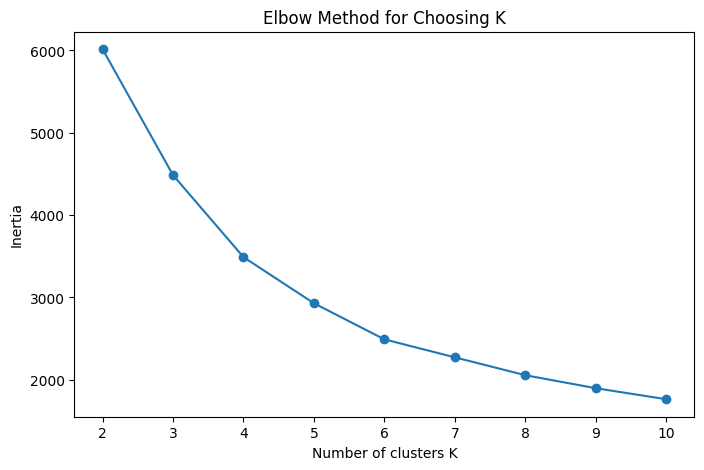

In [12]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of clusters K")
plt.ylabel("Inertia")
plt.title("Elbow Method for Choosing K")
plt.show()

Cách đọc: Nếu biểu đồ giảm mạnh rồi bắt đầu chậm lại tại K = 3 hoặc K = 4,
thì đó là số cụm hợp lý.

## Kiểm tra Silhouette Score

In [13]:
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.4471
K = 3, Silhouette Score = 0.3418
K = 4, Silhouette Score = 0.3528
K = 5, Silhouette Score = 0.3327
K = 6, Silhouette Score = 0.3327
K = 7, Silhouette Score = 0.3159
K = 8, Silhouette Score = 0.3134
K = 9, Silhouette Score = 0.3071
K = 10, Silhouette Score = 0.2899


Cách hiểu: Silhouette Score càng cao càng tốt.
Nhưng trong bài toán business, không nhất thiết chọn score cao nhất tuyệt đối. Ta cần chọn số cụm dễ giải thích và có ý nghĩa kinh doanh.
- Bài này có thể chọn k = 4

## Huấn luyện K-Means

In [14]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,2
12347.0,2,7,4310.00,3
12348.0,75,4,1797.24,2
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


## Phân tích từng cụm

In [15]:
cluster_summary = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,21.96,1.92,476.15
1,193.68,1.27,317.36
2,82.88,3.62,1622.70
3,14.47,11.83,6693.99


In [16]:
## Đếm số khách trong từng cụm

cluster_count = rfm["Cluster"].value_counts().sort_index()
cluster_count

Cluster
0     868
1    1432
2    1104
3     934
Name: count, dtype: int64

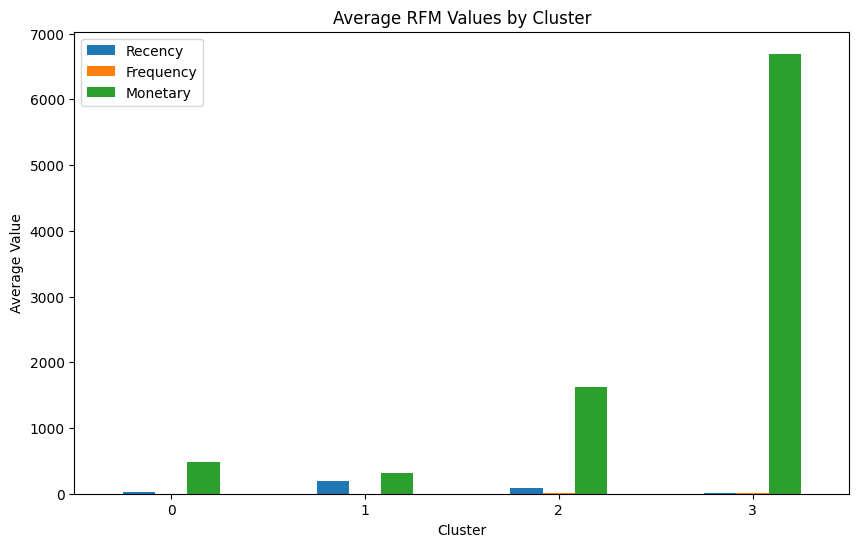

In [22]:
cluster_summary.plot(kind="bar", figsize=(10, 6))
plt.title("Average RFM Values by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()

In [17]:
def label_customer(row):
    if row["Recency"] < rfm["Recency"].median() and row["Frequency"] > rfm["Frequency"].median() and row["Monetary"] > rfm["Monetary"].median():
        return "VIP Customers"
    elif row["Recency"] > rfm["Recency"].median() and row["Frequency"] < rfm["Frequency"].median():
        return "Lost Customers"
    elif row["Frequency"] > rfm["Frequency"].median():
        return "Loyal Customers"
    else:
        return "New or Low Value Customers"

rfm["Segment"] = rfm.apply(label_customer, axis=1)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,2,Lost Customers
12347.0,2,7,4310.00,3,VIP Customers
12348.0,75,4,1797.24,2,Loyal Customers
12349.0,19,1,1757.55,0,New or Low Value Customers
12350.0,310,1,334.40,1,Lost Customers


## Visualize cụm khách hàng

### Frequency vs Monetary

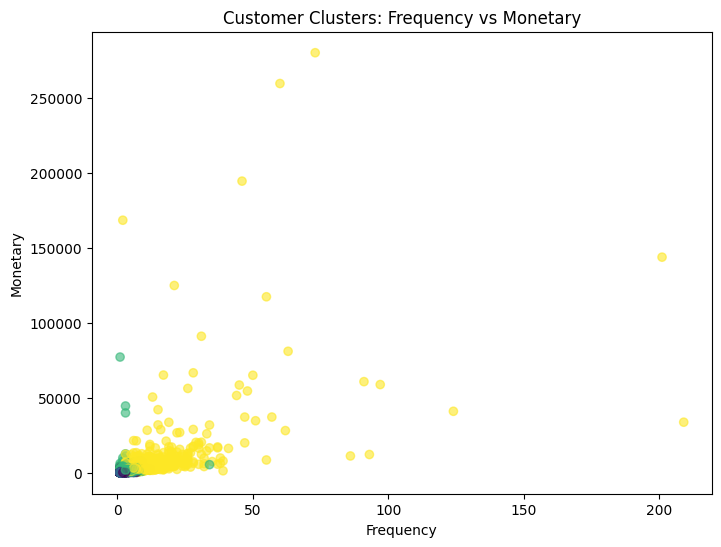

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(rfm["Frequency"], rfm["Monetary"], c=rfm["Cluster"], alpha=0.6)
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Clusters: Frequency vs Monetary")
plt.show()

### Recency vs Monetary

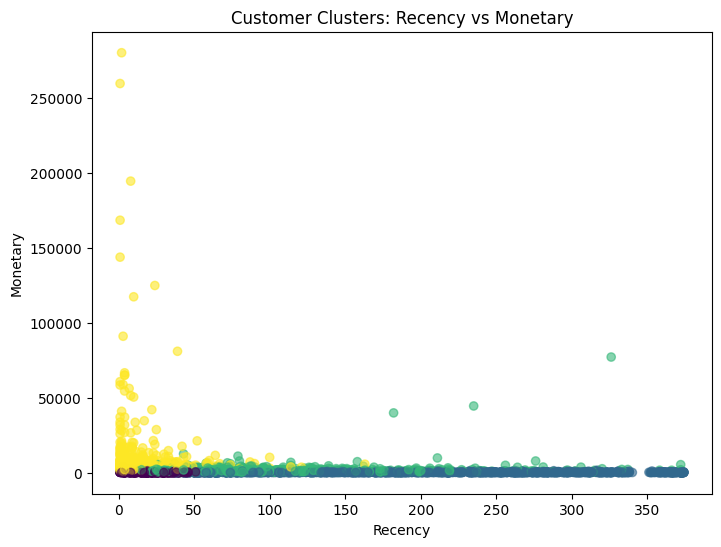

In [26]:
plt.figure(figsize=(8, 6))
plt.scatter(rfm["Recency"], rfm["Monetary"], c=rfm["Cluster"], alpha=0.6)
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("Customer Clusters: Recency vs Monetary")
plt.show()

# Vẽ dữ liệu sau khi giảm chiều bằng PCA
## Ý tưởng
Ban đầu dữ liệu sau chuẩn hóa là:
```
rfm_scaled
```

Dữ liệu này có 3 chiều:

```
Recency, Frequency, Monetary
```

Ta dùng PCA:
```
3 chiều → 2 chiều
```
Sau đó vẽ:
```
Trục X: PCA Component 1
Trục Y: PCA Component 2
Màu: Cluster
```

## Code nối tiếp từ bài trước
Bạn thêm phần này sau khi đã chạy K-Means.

### 1. Import PCA

In [18]:
from sklearn.decomposition import PCA

### 2. Giảm chiều dữ liệu bằng PCA

In [20]:
pca = PCA(n_components=2)

rfm_pca = pca.fit_transform(rfm_scaled)

rfm_pca

array([[-0.26345444,  1.82840005],
       [ 2.69845173, -0.57076887],
       [ 0.59080714,  0.81635555],
       ...,
       [-0.31478872, -1.74700007],
       [ 2.78889404, -0.47106384],
       [ 0.59373853,  0.36710895]], shape=(4338, 2))

Kết quả rfm_pca là dữ liệu mới có 2 cột:
```
PCA1, PCA2
```

### 3. Tạo DataFrame PCA

In [21]:
pca_df = pd.DataFrame(
    data=rfm_pca,
    columns=["PCA1", "PCA2"],
    index=rfm.index
)

pca_df["Cluster"] = rfm["Cluster"].values

pca_df.head()

,PCA1,PCA2,Cluster
CustomerID,,,
12346.0,-0.263454,1.828400,2
12347.0,2.698452,-0.570769,3
12348.0,0.590807,0.816356,2
12349.0,0.182614,-0.473327,0
12350.0,-1.790224,0.669963,1


### 4. Vẽ dữ liệu sau khi giảm chiều bằng PCA


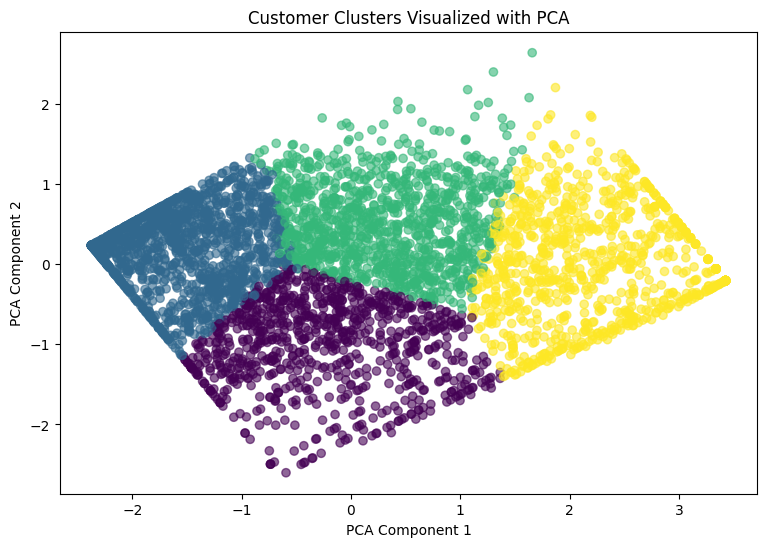

In [22]:
plt.figure(figsize=(9, 6))

plt.scatter(
    pca_df["PCA1"],
    pca_df["PCA2"],
    c=pca_df["Cluster"],
    alpha=0.6
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Clusters Visualized with PCA")
plt.show()

Ý nghĩa: 
- Mỗi điểm = 1 khách hàng
- Màu sắc = cụm khách hàng
- Các điểm gần nhau = hành vi mua hàng giống nhau
- Các điểm xa nhau = hành vi mua hàng khác nhau

### 5. Kiểm tra PCA giữ lại bao nhiêu thông tin

In [23]:
explained_variance = pca.explained_variance_ratio_

print("Explained variance ratio:", explained_variance)
print("Total explained variance:", explained_variance.sum())

Explained variance ratio: [0.75249979 0.1882165 ]
Total explained variance: 0.9407162894825818


Ý nghĩa: 
- PCA1 giữ khoảng 75% thông tin
- PCA2 giữ khoảng 18% thông tin
- Tổng cộng biểu đồ 2D giữ được khoảng 90% thông tin ban đầu

### 6. Vẽ đẹp hơn với tên cụm
Sau khi bạn có cluster_summary, có thể tự đặt tên cụm. Ví dụ:

In [24]:
cluster_names = {
    0: "Low Value",
    1: "VIP",
    2: "Potential",
    3: "Lost"
}

pca_df["Segment"] = pca_df["Cluster"].map(cluster_names)

Sau đó vẽ từng cụm riêng:

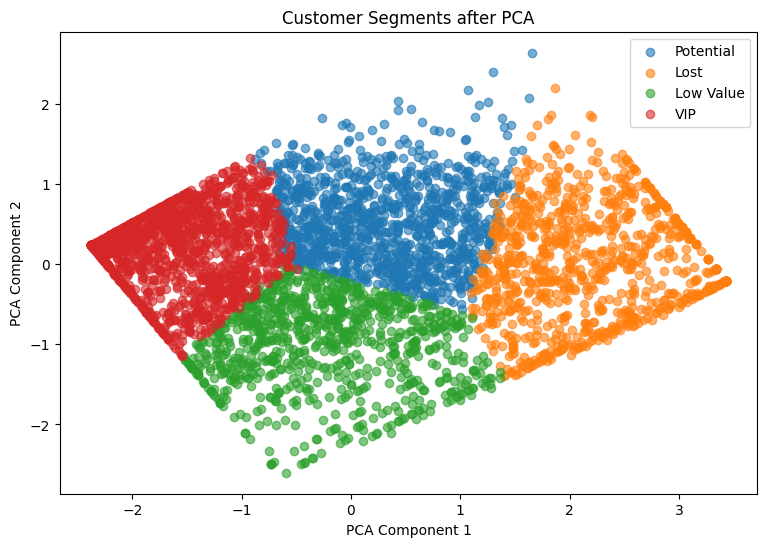

In [25]:
plt.figure(figsize=(9, 6))

for segment in pca_df["Segment"].unique():
    subset = pca_df[pca_df["Segment"] == segment]
    
    plt.scatter(
        subset["PCA1"],
        subset["PCA2"],
        label=segment,
        alpha=0.6
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Segments after PCA")
plt.legend()
plt.show()

### 7. Có nên PCA trước rồi mới K-Means không?

Có 2 cách:

**Cách 1: K-Means trước, PCA chỉ để vẽ**

Đây là cách mình khuyên dùng cho bài của bạn.
```
RFM scaled → K-Means clustering
RFM scaled → PCA 2D → visualize cluster
```
Ưu điểm:

Model phân cụm dựa trên đầy đủ dữ liệu gốc.
PCA chỉ dùng để trực quan hóa.
Dễ giải thích, hợp bài học.

**Cách 2: PCA trước, rồi K-Means sau**
```
RFM scaled → PCA → K-Means
```
Cách này cũng được, nhưng trong bài này chỉ có 3 features RFM nên không quá cần thiết. PCA thường hữu ích hơn khi có nhiều chiều dữ liệu, ví dụ 20, 50, 100 features.